## **Libraries Imported**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Data Cleaning

In [3]:
file_path = "enhanced_student_habits_performance_dataset.csv"
df = pd.read_csv(file_path)

print("Original shape:", df.shape)
print("Original columns:")
print(df.columns.tolist())

# 2. Standardize column names

df.columns = (
    df.columns.str.strip().str.lower().str.replace(" ", "_"))

# -----------------------------
# 3. Remove exact duplicate rows
# -----------------------------
df = df.drop_duplicates()

# Remove duplicate student_id rows if any
if "student_id" in df.columns:
    df = df.drop_duplicates(subset=["student_id"])

# -----------------------------
# 4. Check required project columns
# -----------------------------
required_cols = [
    "student_id",
    "sleep_hours",
    "exam_score"
]

missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# -----------------------------
# 5. Convert categorical text columns
# -----------------------------
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# Optional: standardize title case for some text columns
text_cols_to_standardize = [
    "gender",
    "major",
    "part_time_job",
    "diet_quality",
    "parental_education_level",
    "internet_quality",
    "extracurricular_participation",
    "dropout_risk",
    "study_environment",
    "access_to_tutoring",
    "family_income_range",
    "learning_style"
]

for col in text_cols_to_standardize:
    if col in df.columns:
        df[col] = df[col].str.title()

# -----------------------------
# 6. Convert numeric columns properly
# -----------------------------
numeric_cols = [
    "age",
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "mental_health_rating",
    "previous_gpa",
    "semester",
    "stress_level",
    "social_activity",
    "screen_time",
    "parental_support_level",
    "motivation_level",
    "exam_anxiety_score",
    "time_management_score",
    "exam_score"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------
# 7. Handle missing values
# -----------------------------
# Numeric: fill with median
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Categorical: fill with mode
for col in categorical_cols:
    if col in df.columns:
        mode_value = df[col].mode(dropna=True)
        if len(mode_value) > 0:
            df[col] = df[col].replace("nan", np.nan)
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

# -----------------------------
# 8. Remove impossible / invalid values
# -----------------------------
# Keep only realistic rows based on domain logic
valid_conditions = pd.Series(True, index=df.index)

if "age" in df.columns:
    valid_conditions &= df["age"].between(15, 35)

if "sleep_hours" in df.columns:
    valid_conditions &= df["sleep_hours"].between(0, 24)

if "study_hours_per_day" in df.columns:
    valid_conditions &= df["study_hours_per_day"].between(0, 24)

if "social_media_hours" in df.columns:
    valid_conditions &= df["social_media_hours"].between(0, 24)

if "netflix_hours" in df.columns:
    valid_conditions &= df["netflix_hours"].between(0, 24)

if "screen_time" in df.columns:
    valid_conditions &= df["screen_time"].between(0, 24)

if "attendance_percentage" in df.columns:
    valid_conditions &= df["attendance_percentage"].between(0, 100)

if "previous_gpa" in df.columns:
    valid_conditions &= df["previous_gpa"].between(0, 4)

if "exam_score" in df.columns:
    valid_conditions &= df["exam_score"].between(0, 100)

if "mental_health_rating" in df.columns:
    valid_conditions &= df["mental_health_rating"].between(1, 10)

if "stress_level" in df.columns:
    valid_conditions &= df["stress_level"].between(1, 10)

if "time_management_score" in df.columns:
    valid_conditions &= df["time_management_score"].between(1, 10)

if "motivation_level" in df.columns:
    valid_conditions &= df["motivation_level"].between(1, 10)

if "parental_support_level" in df.columns:
    valid_conditions &= df["parental_support_level"].between(1, 10)

if "exercise_frequency" in df.columns:
    valid_conditions &= df["exercise_frequency"].between(0, 7)

if "semester" in df.columns:
    valid_conditions &= df["semester"].between(1, 12)

df = df[valid_conditions].copy()

# -----------------------------
# 9. Clip values to safe ranges
#    (extra protection after filtering)
# -----------------------------
clip_ranges = {
    "age": (15, 35),
    "study_hours_per_day": (0, 24),
    "social_media_hours": (0, 24),
    "netflix_hours": (0, 24),
    "attendance_percentage": (0, 100),
    "sleep_hours": (0, 24),
    "exercise_frequency": (0, 7),
    "mental_health_rating": (1, 10),
    "previous_gpa": (0, 4),
    "semester": (1, 12),
    "stress_level": (1, 10),
    "social_activity": (0, 10),
    "screen_time": (0, 24),
    "parental_support_level": (1, 10),
    "motivation_level": (1, 10),
    "exam_anxiety_score": (1, 10),
    "time_management_score": (1, 10),
    "exam_score": (0, 100)
}

for col, (low, high) in clip_ranges.items():
    if col in df.columns:
        df[col] = df[col].clip(lower=low, upper=high)

# -----------------------------
# 10. Rename columns for project readability
# -----------------------------
rename_map = {
    "student_id": "student_id",
    "sleep_hours": "hours_slept",
    "exam_score": "grade",
    "study_hours_per_day": "study_hours_per_day",
    "attendance_percentage": "attendance_percentage",
    "previous_gpa": "previous_gpa",
    "stress_level": "stress_level",
    "extracurricular_participation": "extracurricular_participation",
    "gender": "gender",
    "age": "age"
}

df = df.rename(columns=rename_map)


if "subject" not in df.columns:
    df["subject"] = "General"

# -----------------------------
# 12. Reorder important columns first
# -----------------------------
preferred_order = [
    "student_id",
    "hours_slept",
    "subject",
    "grade",
    "age",
    "gender",
    "study_hours_per_day",
    "attendance_percentage",
    "stress_level",
    "extracurricular_participation",
    "previous_gpa"
]

existing_first = [col for col in preferred_order if col in df.columns]
remaining_cols = [col for col in df.columns if col not in existing_first]
df = df[existing_first + remaining_cols]

output_file = "cleaned_student_sleep_performance_dataset.csv"
df.to_csv(output_file, index=False)


print(df.head())
print(df.info())

Original shape: (80000, 31)
Original columns:
['student_id', 'age', 'gender', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score']
   student_id  hours_slept  subject  grade  age  gender  study_hours_per_day  \
0      100000          6.2  General    100   26    Male             7.645367   
1      100001          7.2  General     99   28    Male             5.700000   
2      100002          9.2  General     98   17    Male             2.400000   
3      100003          4.2  General    100   2

# Encode Categorical Variables

In [4]:
df = pd.get_dummies(df, columns=['age', 'gender', 'extracurricular_participation', 'subject'], drop_first=True)

# Exploratory Data Analysis (EDA)

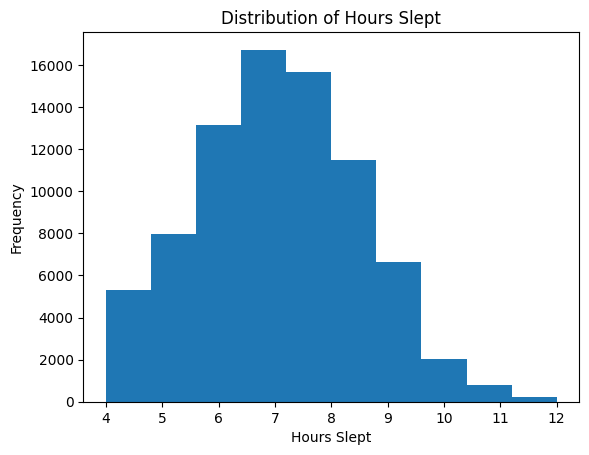

In [7]:
plt.hist(df['hours_slept'])
plt.title("Distribution of Hours Slept")
plt.xlabel("Hours Slept")
plt.ylabel("Frequency")
plt.show()

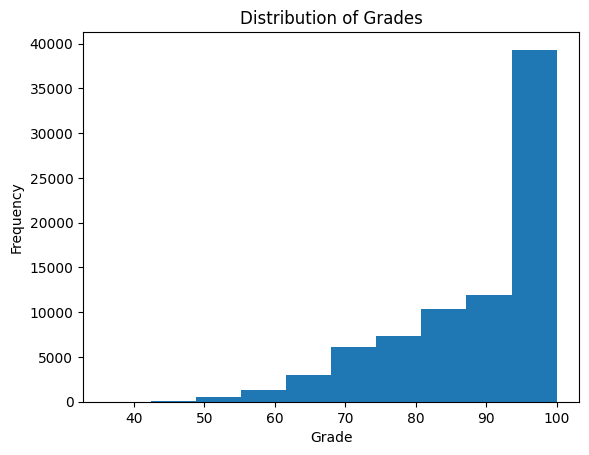

In [11]:
plt.hist(df['grade'])
plt.title("Distribution of Grades")
plt.xlabel("Grade")
plt.ylabel("Frequency")
plt.show()

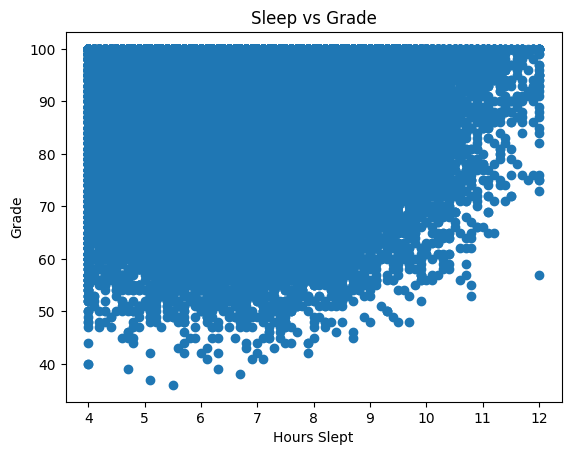

In [14]:
plt.scatter(df['hours_slept'], df['grade'])
plt.xlabel("Hours Slept")
plt.ylabel("Grade")
plt.title("Sleep vs Grade")
plt.show()

# Modeling (Linear Regression)

In [17]:
X = df.drop(columns=['student_id', 'grade'])
y = df['grade']
X = pd.get_dummies(X, drop_first=True)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(Xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Predictions

In [18]:
ypred = model.predict(Xtest)

# Evaluation

In [19]:
mse = mean_squared_error(ytest, ypred)
print("MSE:", mse)
r_2 = r2_score(ytest, ypred)
print("R^2:", r_2)

MSE: 17.550221146231824
R^2: 0.8703713039346599


# Residual Plot

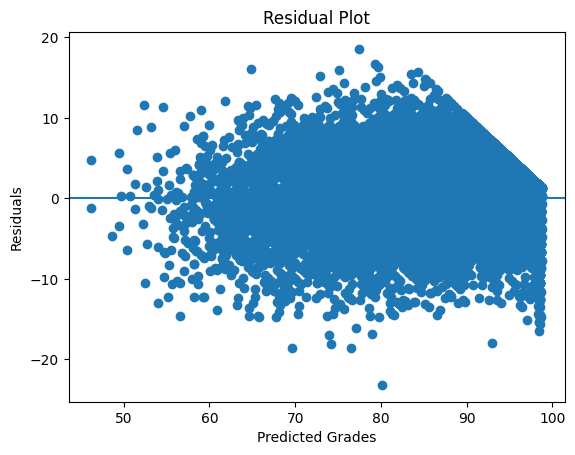

In [20]:
r = ytest - ypred

plt.scatter(ypred, r)
plt.axhline(y=0)
plt.xlabel("Predicted Grades")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Interpret Coefficients

In [21]:
c_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(c_df.sort_values(by="Coefficient", ascending=False))

                                  Feature  Coefficient
4                            previous_gpa    23.349232
22                                 age_23     0.096923
39   parental_education_level_High School     0.086170
35                       major_Psychology     0.051622
54                 learning_style_Reading     0.049500
6                           netflix_hours     0.048647
1                     study_hours_per_day     0.040268
5                      social_media_hours     0.036791
51                family_income_range_Low     0.032924
41           parental_education_level_Phd     0.030604
32                         major_Business     0.028089
14                     exam_anxiety_score     0.026664
34                      major_Engineering     0.023872
53             learning_style_Kinesthetic     0.022809
50                 access_to_tutoring_Yes     0.020948
17                                 age_18     0.018341
40        parental_education_level_Master     0.015799
42  parent

# Simple Model

In [23]:
Xsimple = df[['hours_slept']]
y = df['grade']

Xtrain, Xtest, ytrain, ytest = train_test_split(Xsimple, y, test_size=0.2, random_state=42)

m_simple = LinearRegression()
m_simple.fit(Xtrain, ytrain)

y_p_simple = m_simple.predict(Xtest)

print("R^2 (Simple):", r2_score(ytest, y_p_simple))

R^2 (Simple): 0.00661611609894186


# Regression Line Visualization

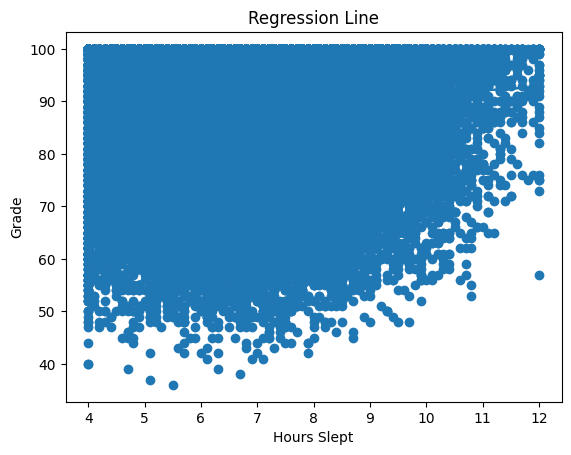

In [24]:
plt.scatter(Xsimple, y)
plt.plot(Xsimple, m_simple.predict(Xsimple))
plt.xlabel("Hours Slept")
plt.ylabel("Grade")
plt.title("Regression Line")
plt.show()